In [35]:
# Importações básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Bibliotecas especializadas
# import missingno as msno
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
# import category_encoders as ce
import math
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

print(" Bibliotecas importadas!")

 Bibliotecas importadas!


Adicionando a feature "Day"

In [36]:
from pathlib import Path
import pandas as pd

# Caminhos
RAW_DIR = Path("../../data/Airbnb Prices in European Cities/raw/")
PROCESSED_DIR = Path("../../data/Airbnb Prices in European Cities/processed/")

files = ["barcelona_weekdays.csv", "barcelona_weekends.csv"]

dfs = []

for fname in files:
    file_path = RAW_DIR / fname
    print("📂 Lendo arquivo:", file_path)

    df_temp = pd.read_csv(file_path)

    if "weekdays" in fname:
        df_temp["day"] = 1
    elif "weekends" in fname:
        df_temp["day"] = 0

    dfs.append(df_temp)

# Juntar weekday + weekend
df = pd.concat(dfs, ignore_index=True)

print("\n✔ Dados combinados!")
print("Total de linhas:", len(df))
print("Colunas:", df.columns.tolist())

# Checagem rápida
print(df["day"].value_counts())


📂 Lendo arquivo: ../../data/Airbnb Prices in European Cities/raw/barcelona_weekdays.csv
📂 Lendo arquivo: ../../data/Airbnb Prices in European Cities/raw/barcelona_weekends.csv

✔ Dados combinados!
Total de linhas: 2833
Colunas: ['Unnamed: 0', 'realSum', 'room_type', 'room_shared', 'room_private', 'person_capacity', 'host_is_superhost', 'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'attr_index', 'attr_index_norm', 'rest_index', 'rest_index_norm', 'lng', 'lat', 'day']
day
1    1555
0    1278
Name: count, dtype: int64


Remover colunas irrelevantes 

In [37]:
cols_remove = [
    "rest_index",
    "attr_index_norm",
    "rest_index_norm",
    "room_shared",
    "room_private",
    "lat",
    "lng",
    "version https://git-lfs.github.com/spec/v1"
]

df = df.drop(columns=cols_remove, errors="ignore")

df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print("\n✔ Dados combinados!")
print("Total de linhas:", len(df))
print("Colunas:", df.columns.tolist())



✔ Dados combinados!
Total de linhas: 2833
Colunas: ['realSum', 'room_type', 'person_capacity', 'host_is_superhost', 'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'attr_index', 'day']


Tratamento de Outliers (transformações)


📌 ESTATÍSTICAS DEPOIS DAS TRANSFORMAÇÕES


,realSum,attr_index
count,2833.000000,2833.000000
mean,5.475206,5.997340
std,0.566221,0.522312
min,4.256864,4.551984
25%,5.086491,5.648167
50%,5.343766,5.959096
75%,5.801478,6.381345
max,8.845734,7.984508


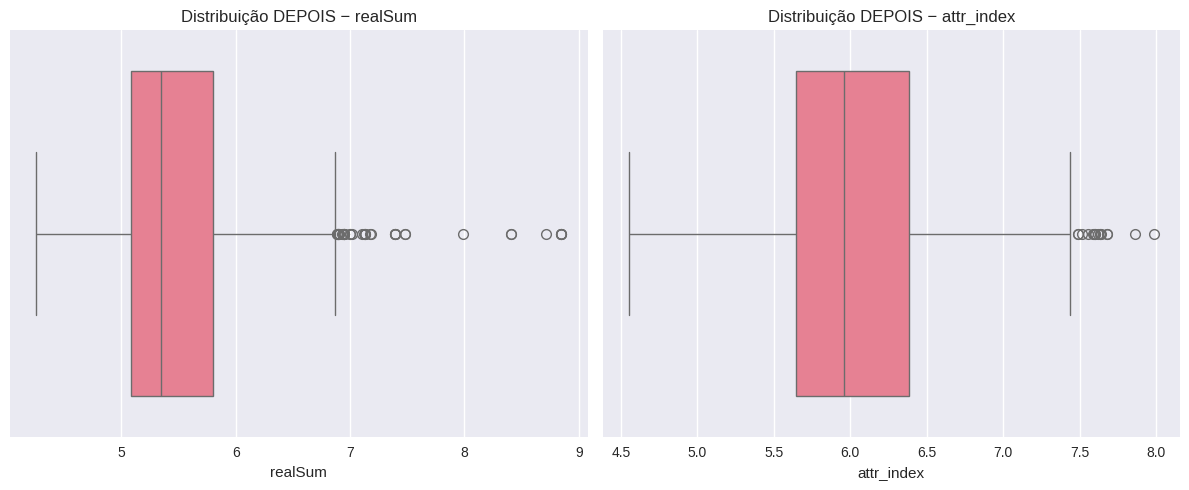

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# log1p = log(1 + x) → evita log(0)
if "realSum" in df.columns:
    df["realSum"] = np.log1p(df["realSum"])

if "attr_index" in df.columns:
    df["attr_index"] = np.log1p(df["attr_index"])

print("\n📌 ESTATÍSTICAS DEPOIS DAS TRANSFORMAÇÕES")
display(df[["realSum", "attr_index"]].describe())

plt.figure(figsize=(12, 5))
for i, col in enumerate(["realSum", "attr_index"]):
    plt.subplot(1, 2, i+1)
    sns.boxplot(x=df[col], orient='h')
    plt.title(f"Distribuição DEPOIS − {col}")
plt.tight_layout()
plt.show()

Remover registros com valores ausentes

In [39]:
df = df.dropna()
print("Após remover NaN:", df.shape)

Após remover NaN: (2833, 13)


Transformar as Variaveis Categóricas em Numéricas

In [40]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols

Index(['room_type'], dtype='object')

In [41]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("✔ Após One-Hot Encoding:", df.shape)

✔ Após One-Hot Encoding: (2833, 14)


Feature Scaling (normalização de variaveis numéricas)

In [42]:
from sklearn.preprocessing import MinMaxScaler
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


Separar conjunto de teste e treinamento

In [43]:
from sklearn.model_selection import train_test_split

# variável alvo
target = 'realSum'  # ajuste se necessário

# separação X e y
X = df.drop(columns=[target])
y = df[target]

# split fixo (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

Salvar arquivos Teste e Treinamento

In [44]:
# reconstruir DataFrames
train_df = X_train.copy()
train_df[target] = y_train

test_df = X_test.copy()
test_df[target] = y_test

# salvar arquivos
train_file = PROCESSED_DIR / "barcelona_treino.csv"
test_file = PROCESSED_DIR / "barcelona_teste.csv"

train_df.to_csv(train_file, index=False)
test_df.to_csv(test_file, index=False)

print("✔ Conjuntos salvos:")
print("  Treino:", train_file)
print("  Teste :", test_file)

✔ Conjuntos salvos:
  Treino: ../../data/Airbnb Prices in European Cities/processed/barcelona_treino.csv
  Teste : ../../data/Airbnb Prices in European Cities/processed/barcelona_teste.csv


Separando weekdays processados em teste e treino /weekends processados em teste e treino

In [45]:
# Separar os dados em weekdays e weekends
# Separar os dados
weekdays_df = df[df["day"] == 1].drop(columns=["day"])
weekends_df = df[df["day"] == 0].drop(columns=["day"])

# Dividir weekdays em treino (80%) e teste (20%)
weekdays_train, weekdays_test = train_test_split(weekdays_df, test_size=0.2, random_state=42)

# Dividir weekends em treino (80%) e teste (20%)
weekends_train, weekends_test = train_test_split(weekends_df, test_size=0.2, random_state=42)

# Salvar os arquivos de treino e teste
# Weekdays
weekdays_train_file = PROCESSED_DIR / "barcelona_weekdays_treino.csv"
weekdays_test_file = PROCESSED_DIR / "barcelona_weekdays_teste.csv"

weekdays_train.to_csv(weekdays_train_file, index=False)
weekdays_test.to_csv(weekdays_test_file, index=False)

# Weekends
weekends_train_file = PROCESSED_DIR / "barcelona_weekends_treino.csv"
weekends_test_file = PROCESSED_DIR / "barcelona_weekends_teste.csv"

weekends_train.to_csv(weekends_train_file, index=False)
weekends_test.to_csv(weekends_test_file, index=False)

print("\n✔ Conjuntos salvos:")
print("  Treino (weekdays):", weekdays_train_file)
print("  Teste  (weekdays):", weekdays_test_file)
print("  Treino (weekends):", weekends_train_file)
print("  Teste  (weekends):", weekends_test_file)


✔ Conjuntos salvos:
  Treino (weekdays): ../../data/Airbnb Prices in European Cities/processed/barcelona_weekdays_treino.csv
  Teste  (weekdays): ../../data/Airbnb Prices in European Cities/processed/barcelona_weekdays_teste.csv
  Treino (weekends): ../../data/Airbnb Prices in European Cities/processed/barcelona_weekends_treino.csv
  Teste  (weekends): ../../data/Airbnb Prices in European Cities/processed/barcelona_weekends_teste.csv
